# Split CSV 분석

`SPLIT_CSV` 경로를 지정하면 가장 마지막 R 컬럼의 파티션별 선택 분포를 시각화합니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

SPLIT_CSV = "../checkpoints/stage1/agg/R03r02/split.csv"

df = pd.read_csv(SPLIT_CSV)

# 정수 컬럼 Int64 복원
df["Partition_ID"] = df["Partition_ID"].astype("Int64")
for col in df.columns:
    if col.startswith("R") and col[1:].isdigit():
        df[col] = df[col].astype("Int64")
if "pool" in df.columns:
    df["pool"] = df["pool"].astype("Int64")

# 마지막 R 컬럼 자동 탐색
r_cols = sorted([c for c in df.columns if c.startswith("R") and c[1:].isdigit()])
last_r = r_cols[-1]
print(f"CSV: {SPLIT_CSV}")
print(f"Total rows: {len(df)}  |  R columns: {r_cols}  |  plotting: {last_r}")
df.head()

CSV: ../checkpoints/stage1/agg/R03r02/split.csv
Total rows: 1251  |  R columns: ['R00', 'R01', 'R02', 'R03']  |  plotting: R03


,Partition_ID,Subject_ID,TrainOrVal,R00,R01,R02,R03
0,1,FeTS2022_01341,train,0,0,1,0
1,1,FeTS2022_01333,train,0,1,0,1
2,1,FeTS2022_01077,train,0,0,0,0
3,1,FeTS2022_01054,train,0,0,0,0
4,1,FeTS2022_00285,train,0,1,0,0


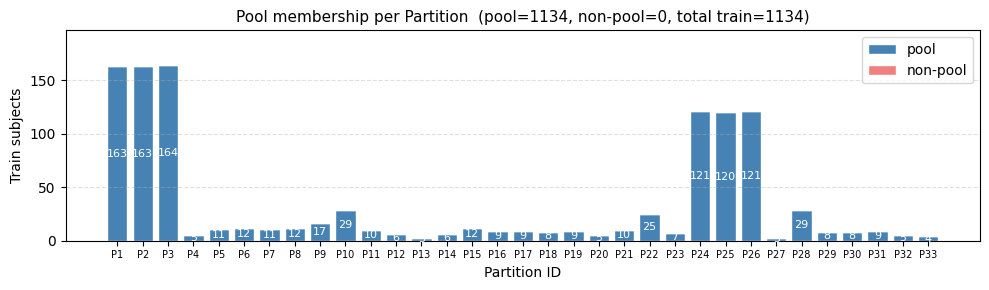

In [3]:
# 공통 변수
train_df = df[df["TrainOrVal"] == "train"]
has_pool = "pool" in df.columns
pool_df  = train_df[train_df["pool"] == 1] if has_pool else train_df
masked   = int((train_df["pool"] == 0).sum()) if has_pool else 0
total_train = len(train_df)

# Pool 분포 (stacked bar: pool=1 / pool=0)
all_counts  = train_df.groupby("Partition_ID").size()
pool_counts = pool_df.groupby("Partition_ID").size().reindex(all_counts.index, fill_value=0)
nonp_counts = all_counts - pool_counts
x_labels = [f"P{p}" for p in all_counts.index]

fig, ax = plt.subplots(figsize=(10, 3))
bars_pool = ax.bar(x_labels, pool_counts.values, color="steelblue", edgecolor="white", label="pool")
bars_nonp = ax.bar(x_labels, nonp_counts.values, bottom=pool_counts.values,
                   color="lightcoral", edgecolor="white", label="non-pool")
ax.bar_label(bars_pool, labels=[str(v) if v > 0 else "" for v in pool_counts.values],
             label_type="center", fontsize=8, color="white")
ax.set_title(f"Pool membership per Partition  (pool={total_train - masked}, non-pool={masked}, total train={total_train})", fontsize=11)
ax.set_xlabel("Partition ID")
ax.set_ylabel("Train subjects")
ax.set_ylim(0, all_counts.max() * 1.2)
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
plt.show()

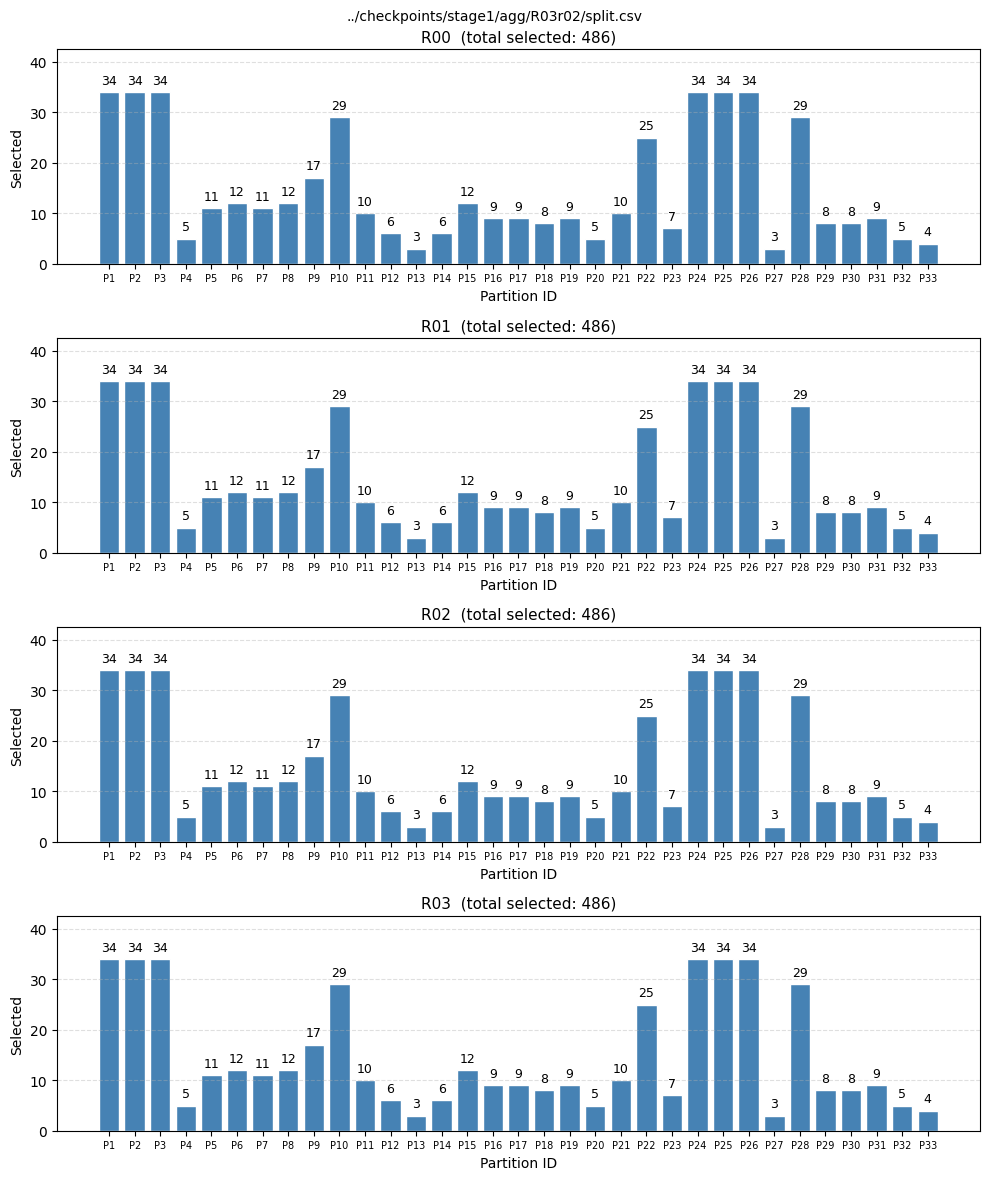


   Partition         R00         R01         R02         R03
           1    34/163     34/163     34/163     34/163 
           2    34/163     34/163     34/163     34/163 
           3    34/164     34/164     34/164     34/164 
           4     5/5        5/5        5/5        5/5   
           5    11/11      11/11      11/11      11/11  
           6    12/12      12/12      12/12      12/12  
           7    11/11      11/11      11/11      11/11  
           8    12/12      12/12      12/12      12/12  
           9    17/17      17/17      17/17      17/17  
          10    29/29      29/29      29/29      29/29  
          11    10/10      10/10      10/10      10/10  
          12     6/6        6/6        6/6        6/6   
          13     3/3        3/3        3/3        3/3   
          14     6/6        6/6        6/6        6/6   
          15    12/12      12/12      12/12      12/12  
          16     9/9        9/9        9/9        9/9   
          17     9/9      

In [4]:
# R00 ~ 마지막 R 분포
fig, axes = plt.subplots(len(r_cols), 1, figsize=(10, 3 * len(r_cols)))
if len(r_cols) == 1:
    axes = [axes]

for ax, r_col in zip(axes, r_cols):
    selected = pool_df.groupby("Partition_ID")[r_col].sum()
    total_selected = int(selected.sum())
    bars = ax.bar([f"P{p}" for p in selected.index], selected.values,
                  color="steelblue", edgecolor="white")
    ax.bar_label(bars, padding=4, fontsize=9)
    ax.set_title(f"{r_col}  (total selected: {total_selected})", fontsize=11)
    ax.set_xlabel("Partition ID")
    ax.set_ylabel("Selected")
    ax.set_ylim(0, selected.max() * 1.25)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis="x", labelsize=7)

fig.suptitle(f"{SPLIT_CSV}", fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n{'Partition':>12}", end="")
for r_col in r_cols:
    print(f"  {r_col:>10}", end="")
print()
for p in sorted(pool_df["Partition_ID"].dropna().unique()):
    print(f"{p:>12}", end="")
    for r_col in r_cols:
        n_pool = len(pool_df[pool_df["Partition_ID"] == p])
        n_sel  = int(pool_df[pool_df["Partition_ID"] == p][r_col].sum())
        print(f"  {n_sel:>4}/{n_pool:<4}", end="")
    print()